In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/basil/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']

In [3]:
case_study_range_eddy = ['2012-07-05', '2012-08-31']
case_study_range_fil = ['2012-08-06', '2012-08-19']

In [4]:
Eta_files, Eta_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[0],file_end='nc')
Eta = xr.open_mfdataset(Eta_filepaths)

In [5]:
Eta = xr.merge([Eta,grid])

In [8]:
Eta=Eta.set_coords({'XC','YC'}).isel(k=0)


<xarray.Dataset>
Dimensions:  (time: 9119, i: 1486, j: 672)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 0 1 2 3 4 5 6 7 ... 1479 1480 1481 1482 1483 1484 1485
  * j        (j) int64 0 1 2 3 4 5 6 7 8 ... 663 664 665 666 667 668 669 670 671
    k        int64 0
Data variables: (12/15)
    Eta      (time, i, j) float32 dask.array<chunksize=(1, 1486, 672), meta=np.ndarray>
    DXC      (i, j) float32 ...
    DXG      (i, j) float32 ...
    DXV      (i, j) float32 ...
    DYC      (i, j) float32 ...
    DYG      (i, j) float32 ...
    ...       ...
    RAZ      (i, j) float32 ...
    XC       (i, j) float32 ...
    XG       (i, j) float32 ...
    YC       (i, j) float32 ...
    YG       (i, j) float32 ...
    hFacC    (i, j) float32 ...

In [9]:
extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]
ds = Eta
ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
ds_cut = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever

In [12]:
eta = ds_cut.isel(k=0)

In [18]:
eta_time = eta.time

In [21]:
eta['time'] = np.array(eta_time)

In [22]:
eta.to_netcdf(path_tohd + 'cutouts/ssh_cape_mend_unfilt.nc')

In [4]:
eta = xr.open_dataset(path_tohd + 'cutouts/ssh_cape_mend_unfilt.nc')


In [5]:
eta_filt = tools.filt(eta['Eta'].sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1])),T=33)
eta_filt = tools.filt(eta_filt,T=15)

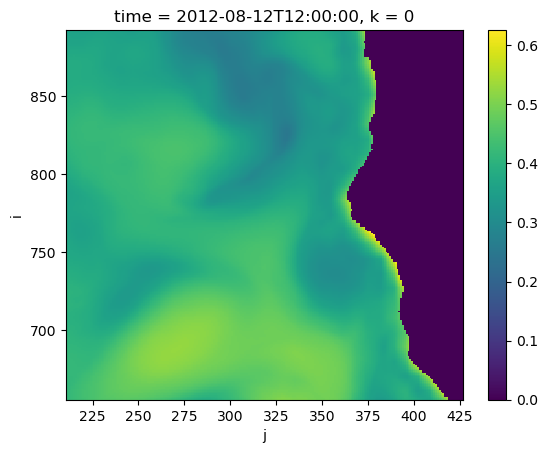

In [18]:
eta_filt.sel(time='2012-08-12').isel(time=12).plot()

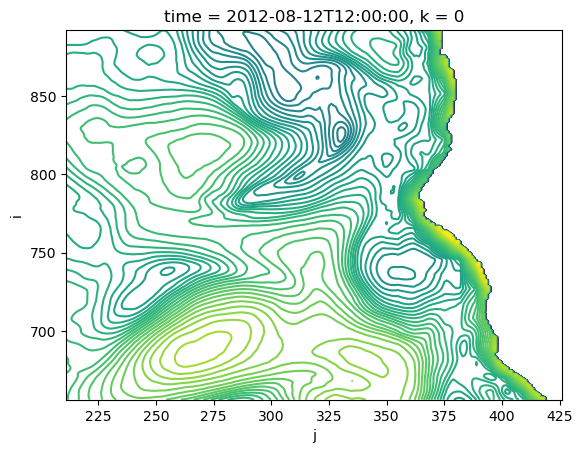

In [17]:
eta_filt.sel(time='2012-08-12').isel(time=12).plot.contour(levels=np.linspace(0,0.6,60))
#grayscale contours

In [ ]:
# connect to HFR and SWOT 